# Composites of other variables based on TAM phases 1-8

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import usefulfunc as uf
import xarray as xr
import os
import gc
from scipy.signal import correlate
from matplotlib.colors import TwoSlopeNorm
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import display, HTML

In [4]:
WORK = os.environ["WORK"]   

## Composites of Different Variables based on TAM phase

In [5]:
zmzanom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')
zmzstack = zmzanom.Z.stack(alltime = ('year', 'time'))
zmzanomtss, lowpzmza = uf.butter1yhighp(zmzstack, 4)

In [6]:
zmupvpdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmupvpdanoms1979_2023.nc')
zmTdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmTdanoms1979_2023.nc')
zmUdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmUdanoms1979_2023.nc')
zmwstardanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmwstardanoms1979_2023.nc')

In [7]:
zmwstardanomts = zmwstardanoms79_23['w*'].stack(alltime = ('year', 'time'))
zmupvpdanomts = zmupvpdanoms79_23.upvp.stack(alltime = ('year', 'time'))
zmUdanomts = zmUdanoms79_23.U.stack(alltime = ('year', 'time'))
zmTdanomts = zmTdanoms79_23.T.stack(alltime = ('year', 'time'))

In [8]:
highpzmupvpa, lowpzmupvpa = uf.butter1yhighp(zmupvpdanomts, 4)
highpzmUa, lowpzmUa = uf.butter1yhighp(zmUdanomts, 4)
highpzmTa, lowpzmTa = uf.butter1yhighp(zmTdanomts, 4)
highpwstara, lowpwstara = uf.butter1yhighp(zmwstardanomts, 4)

In [9]:
edge_trim = 183
zmzanomts = zmzanomtss.isel(alltime=slice(edge_trim, -edge_trim))
highpUshaved = highpzmUa.isel(alltime=slice(edge_trim, -edge_trim))
highpTshaved = highpzmTa.isel(alltime=slice(edge_trim, -edge_trim))
highpupvpshaved = highpzmupvpa.isel(alltime=slice(edge_trim, -edge_trim))
highpwstarshaved = highpwstara.isel(alltime=slice(edge_trim, -edge_trim))

In [10]:
tamp = uf.latavg(zmzanomts, -15,15)
uavg = uf.latavg(highpUshaved, -15,15)
tavg = uf.latavg(highpTshaved, -15,15)
upvpavg = uf.latavg(highpupvpshaved, -15,15)
wstaravg = uf.latavg(highpwstarshaved, -15,15)

In [12]:
tam850 = tamp.sel(level=850)

In [14]:
tam_trop = tamp.sel(level=slice(100,1000))
u_trop = uavg.sel(level=slice(100,1000))
t_trop = tavg.sel(level=slice(100,1000))
upvp_trop = upvpavg.sel(level=slice(100,1000))
wstar_trop = wstaravg.sel(level=slice(100,1000))

In [15]:
def weighted_cov_matrix(Z_m, p_top=0, p_bot=1000):
    """
    Computes the mass-weighted covariance matrix for EOF/PCA analysis.

    Parameters
    ----------
    Z_m   : xr.DataArray (level, alltime)
        Tropical mean GPH anomaly timeseries, highpass filtered.
        Levels must be ascending (1 -> 1000 hPa).
    p_top : float
        Top pressure boundary in hPa (default 0 hPa)
    p_bot : float
        Bottom pressure boundary in hPa (default 1000 hPa)

    Returns
    -------
    C         : np.ndarray (n_level, n_level)
        Mass-weighted covariance matrix
    A_half    : np.ndarray (n_level,)
        Square root of diagonal mass weighting matrix (sqrt of delta_p)
    Z_weighted : np.ndarray (n_level, nt)
        A^(1/2) Z_m -- mass-weighted data matrix, needed for PC computation
    """
    # Extract numpy arrays
    Z_m_vals = Z_m.values                # shape (n_level, nt)
    levels   = Z_m.level.values          # shape (n_level,), ascending
    nt       = Z_m_vals.shape[1]

    # Step 1: compute half-levels (midpoints between adjacent level centers)
    half_levels = 0.5 * (levels[:-1] + levels[1:])  # shape (n_level - 1,)

    # Step 2: add pressure boundaries
    half_levels_full = np.concatenate([[p_top], half_levels, [p_bot]])  # shape (n_level + 1,)

    # Step 3: delta_p -- thickness of layer owned by each level
    delta_p = np.diff(half_levels_full)   # shape (n_level,), all positive (ascending)

    # Sanity check
    expected_total = p_bot - p_top
    assert np.isclose(delta_p.sum(), expected_total), \
        f"delta_p sum {delta_p.sum():.2f} != expected {expected_total:.2f} hPa"

    # Step 4: A^(1/2) diagonal
    A_half = np.sqrt(delta_p)             # shape (n_level,)

    # Step 5: mass-weighted data matrix A^(1/2) Z_m
    Z_weighted = A_half[:, np.newaxis] * Z_m_vals   # shape (n_level, nt)

    # Step 6: covariance matrix
    C = (Z_weighted @ Z_weighted.T) / (nt - 1)      # shape (n_level, n_level)

    # Sanity checks
    assert np.allclose(C, C.T),         "C is not symmetric -- check input data"
    assert np.all(np.diag(C) > 0),     "C has non-positive diagonal entries"

    return C, A_half, Z_weighted

In [16]:
C_trop, A_half_trop, tamwgt_trop = weighted_cov_matrix(tam_trop, p_top=100, p_bot=1000)

In [18]:
# Solve the eigenvalue problem
evaltrop, evectrop = np.linalg.eigh(C_trop)
# eigenvalues shape:  (37,)       ascending order, smallest first
# eigenvectors shape: (37, 37)    column j is the eigenvector for eigenvalue j

# Flip to descending order (EOF1 = most variance first)
evaltrop  = evaltrop[::-1]          # shape (37,)
evectrop = evectrop[:, ::-1]      # shape (37, 37), columns flipped

# Sanity checks
print(f"Eigenvalues (first 5): {evaltrop[:5]}")
print(f"Sum of eigenvalues: {evaltrop.sum():.4f}")
print(f"Total variance from diagonal: {np.diag(C_trop).sum():.4f}")  # must match sum of eigenvalues

# Variance fractions
var_fractions_trop = evaltrop / evaltrop.sum()
print(f"Variance explained by EOF1: {var_fractions_trop[0]*100:.2f}%")
print(f"Variance explained by EOF2: {var_fractions_trop[1]*100:.2f}%")
print(f"Variance explained by EOF1+2: {var_fractions_trop[:2].sum()*100:.2f}%")

Eigenvalues (first 5): [38743.78966357  9444.37379739   391.99016784   128.48407714
    67.81791031]
Sum of eigenvalues: 48827.6081
Total variance from diagonal: 48827.6081
Variance explained by EOF1: 79.35%
Variance explained by EOF2: 19.34%
Variance explained by EOF1+2: 98.69%


In [19]:
PCstrop = evectrop.T @ tamwgt_trop  # shape (n_modes, nt) = (37, 16059)


# Normalize to unit variance and mean center
PCstrop = PCstrop - PCstrop.mean(axis=1, keepdims=True)
PCstrop = PCstrop / PCstrop.std(axis=1, keepdims=True)  # each PC divided by its own std

# Verify
print(f"PC1 mean: {PCstrop[0].mean():.2e}")   # should be ~0 (machine epsilon)
print(f"PC2 mean: {PCstrop[1].mean():.2e}")
print(f"PC1 std:  {PCstrop[0].std():.6f}")    # should be exactly 1.0
print(f"PC2 std:  {PCstrop[1].std():.6f}")

PC1 mean: -1.33e-17
PC2 mean: 9.07e-18
PC1 std:  1.000000
PC2 std:  1.000000


In [20]:
# Flip sign of EOF1 and PC1 + EOF2, PC2
evectrop[:, 0] *= -1
PCstrop[0] *= -1

evectrop[:, 1] *= -1
PCstrop[1] *= -1

# careful with this cell by the way! 
print(f"PC1 vs TAM(850): {np.corrcoef(PCstrop[0], tam850.values)[0,1]:.4f}")
print(f"PC2 vs TAM(850): {np.corrcoef(PCstrop[1], tam850.values)[0,1]:.4f}")

PC1 vs TAM(850): 0.6052
PC2 vs TAM(850): 0.7903


In [21]:
# Phase angle: shape (16059,), degrees in [-180, 180]
phi = np.degrees(np.arctan2(PCstrop[1], PCstrop[0]))

# Amplitude: shape (16059,)
A = np.sqrt(PCstrop[0]**2 + PCstrop[1]**2)

print(f"Phase angle range: {phi.min():.2f} to {phi.max():.2f} degrees")
print(f"Amplitude range: {A.min():.4f} to {A.max():.4f}")
print(f"Amplitude mean: {A.mean():.4f}")

Phase angle range: -179.97 to 180.00 degrees
Amplitude range: 0.0145 to 4.9089
Amplitude mean: 1.2504


In [22]:
# Phase borders
borders = np.arange(-180, 181, 45) - 22.5  
# [-202.5, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 202.5]

# Wrap phi to [0, 360) for clean binning
phi_wrapped = phi % 360  # [0, 360)

borders_wrapped = np.arange(22.5, 360, 45)  
# [22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5]

phase = np.digitize(phi_wrapped, borders_wrapped) + 1
# digitize returns 0-7, so +1 gives 1-8
# phase 1: phi_wrapped < 22.5 OR phi_wrapped >= 337.5 (wrap around)
phase = np.where(phase == 9, 1, phase)
# Quick check
for p in range(1, 9):
    n_days = np.sum(phase == p)
    print(f"Phase {p}: {n_days} days ({n_days/len(phase)*100:.1f}%)")

Phase 1: 2032 days (12.7%)
Phase 2: 2066 days (12.9%)
Phase 3: 1968 days (12.3%)
Phase 4: 2040 days (12.7%)
Phase 5: 2015 days (12.5%)
Phase 6: 1962 days (12.2%)
Phase 7: 1964 days (12.2%)
Phase 8: 2012 days (12.5%)


In [23]:
# Get year coordinate from tamp_trop
years_coord = tam_trop.alltime.coords['year'].values  # shape (16059,)

# Mean amplitude per year
for y in range(1979, 2024):
    mask = years_coord == y
    print(f"{y}: mean amplitude = {A[mask].mean():.3f}")

1979: mean amplitude = 1.467
1980: mean amplitude = 1.088
1981: mean amplitude = 1.073
1982: mean amplitude = 1.362
1983: mean amplitude = 1.343
1984: mean amplitude = 1.411
1985: mean amplitude = 1.185
1986: mean amplitude = 1.261
1987: mean amplitude = 1.149
1988: mean amplitude = 1.163
1989: mean amplitude = 1.239
1990: mean amplitude = 1.190
1991: mean amplitude = 1.317
1992: mean amplitude = 1.127
1993: mean amplitude = 1.281
1994: mean amplitude = 1.101
1995: mean amplitude = 1.259
1996: mean amplitude = 1.310
1997: mean amplitude = 1.470
1998: mean amplitude = 1.463
1999: mean amplitude = 1.182
2000: mean amplitude = 1.181
2001: mean amplitude = 1.304
2002: mean amplitude = 1.359
2003: mean amplitude = 1.078
2004: mean amplitude = 1.109
2005: mean amplitude = 1.366
2006: mean amplitude = 1.373
2007: mean amplitude = 1.368
2008: mean amplitude = 1.215
2009: mean amplitude = 1.244
2010: mean amplitude = 1.191
2011: mean amplitude = 1.103
2012: mean amplitude = 1.167
2013: mean amp

In [26]:
def phase_composite(var, phase, A, threshold=1.0):
    """
    Compute TAM phase composites for any variable.

    Parameters
    ----------
    var       : xr.DataArray (level, alltime) or (alltime,)
                Variable to composite -- already anomaly, latavg'd if needed
    phase     : np.ndarray (alltime,)
                Phase label 1-8 for each day
    A         : np.ndarray (alltime,)
                TAM amplitude for each day
    threshold : float
                Amplitude threshold for active days (default 1.0)

    Returns
    -------
    composite_physical : np.ndarray (n_level, 8) or (8,)
    composite_norm     : np.ndarray (n_level, 8) or (8,)
    """
    n_phases = 8
    shape = var.values.shape

    if var.values.ndim == 2:
        composite = np.zeros((shape[0], n_phases))  # (level, 8)
    else:
        composite = np.zeros(n_phases)              # (8,) for single level

    for p in range(1, n_phases + 1):
        mask = (phase == p) & (A > threshold)
        # mask = (phase == p) & (A > 1.414)
        # mask = (phase == p) & (A > 1.5)
        idx_phase = np.where(mask)[0]

        if var.values.ndim == 2:
            composite[:, p-1] = var.isel(alltime=idx_phase).mean(dim='alltime').values
        else:
            composite[p-1] = var.isel(alltime=idx_phase).mean(dim='alltime').values

    composite_physical = composite.copy()
    var_std = var.std(dim='alltime').values
    composite_norm = composite / var_std[:, np.newaxis] if var.values.ndim == 2 \
                     else composite / var_std

    return composite_physical, composite_norm

In [27]:
comp_temp_physical, comp_temp_norm = phase_composite(t_trop, phase, A, threshold=1.0)

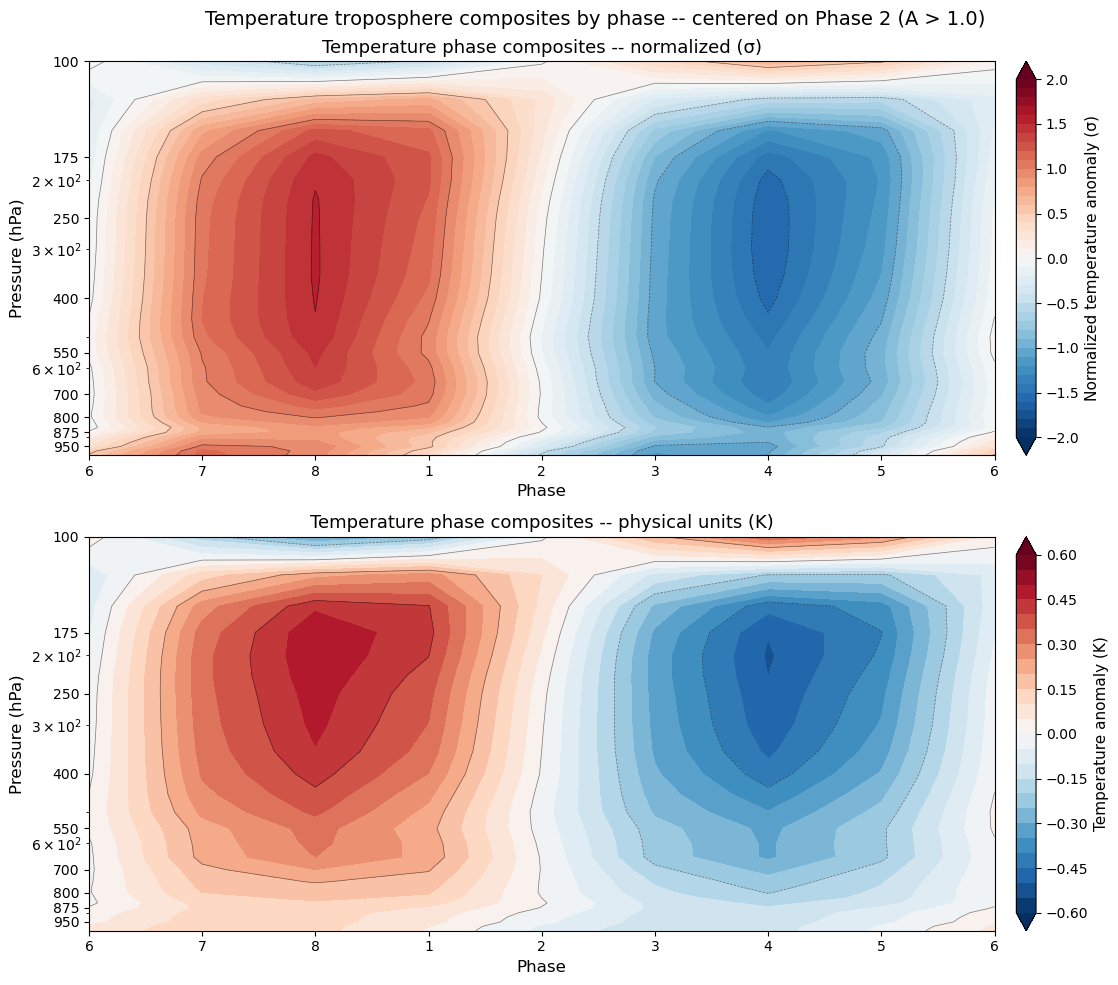

In [31]:
# Phase reordering centered on phase 2
phase_order  = [5, 6, 7, 0, 1, 2, 3, 4, 5]
phase_labels = [6, 7, 8, 1, 2, 3, 4, 5, 6]
phases_centered = np.arange(1, 10)

comp_temp_norm_centered     = comp_temp_norm[:, phase_order]     # shape (27, 9)
comp_temp_physical_centered = comp_temp_physical[:, phase_order] # shape (27, 9)

# Get temperature levels -- confirm same as tam_trop
t_levels = t_trop.level.values

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, t_levels, comp_temp_norm_centered,
    levels=np.arange(-2, 2.1, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, t_levels, comp_temp_norm_centered,
    levels=np.arange(-2, 2.1, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Temperature phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(t_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized temperature anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, t_levels, comp_temp_physical_centered,
    levels=np.arange(-0.6, 0.61, 0.05),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, t_levels, comp_temp_physical_centered,
    levels=np.arange(-0.6, 0.61, 0.2),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Temperature phase composites -- physical units (K)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(t_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('Temperature anomaly (K)', fontsize=11)

plt.suptitle('Temperature troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('Temp_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
comp_wstar_physical, comp_wstar_norm = phase_composite(wstar_trop, phase, A, threshold=1.0)

In [34]:
print(f"w* physical range: {comp_wstar_physical.min():.6f} to {comp_wstar_physical.max():.6f}")
print(f"w* normalized range: {comp_wstar_norm.min():.3f} to {comp_wstar_norm.max():.3f}")

w* physical range: -0.001039 to 0.001300
w* normalized range: -0.293 to 0.331


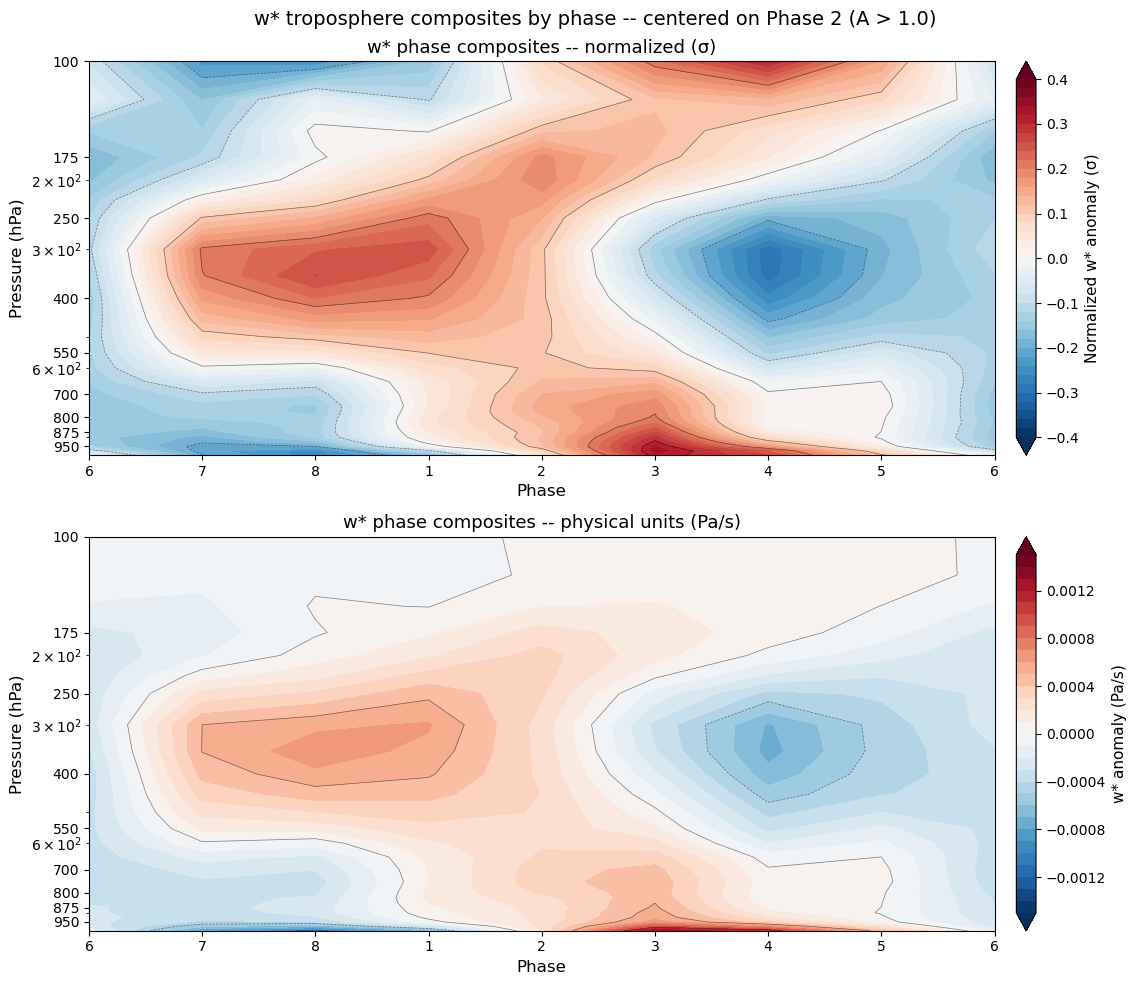

In [35]:
wstar_levels = wstar_trop.level.values

comp_wstar_norm_centered     = comp_wstar_norm[:, phase_order]     # shape (27, 9)
comp_wstar_physical_centered = comp_wstar_physical[:, phase_order] # shape (27, 9)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, wstar_levels, comp_wstar_norm_centered,
    levels=np.arange(-0.4, 0.41, 0.02),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, wstar_levels, comp_wstar_norm_centered,
    levels=np.arange(-0.4, 0.41, 0.1),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w* phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(wstar_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized w* anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, wstar_levels, comp_wstar_physical_centered,
    levels=np.arange(-0.0015, 0.00151, 0.0001),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, wstar_levels, comp_wstar_physical_centered,
    levels=np.arange(-0.0015, 0.00151, 0.0005),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w* phase composites -- physical units (Pa/s)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(wstar_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('w* anomaly (Pa/s)', fontsize=11)

plt.suptitle('w* troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('wstar_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
comp_u_physical, comp_u_norm = phase_composite(u_trop, phase, A, threshold=1.0)

In [37]:
print(f"u physical range: {comp_u_physical.min():.3f} to {comp_u_physical.max():.3f} m/s")
print(f"u normalized range: {comp_u_norm.min():.3f} to {comp_u_norm.max():.3f}")

u physical range: -1.627 to 1.668 m/s
u normalized range: -0.697 to 0.732


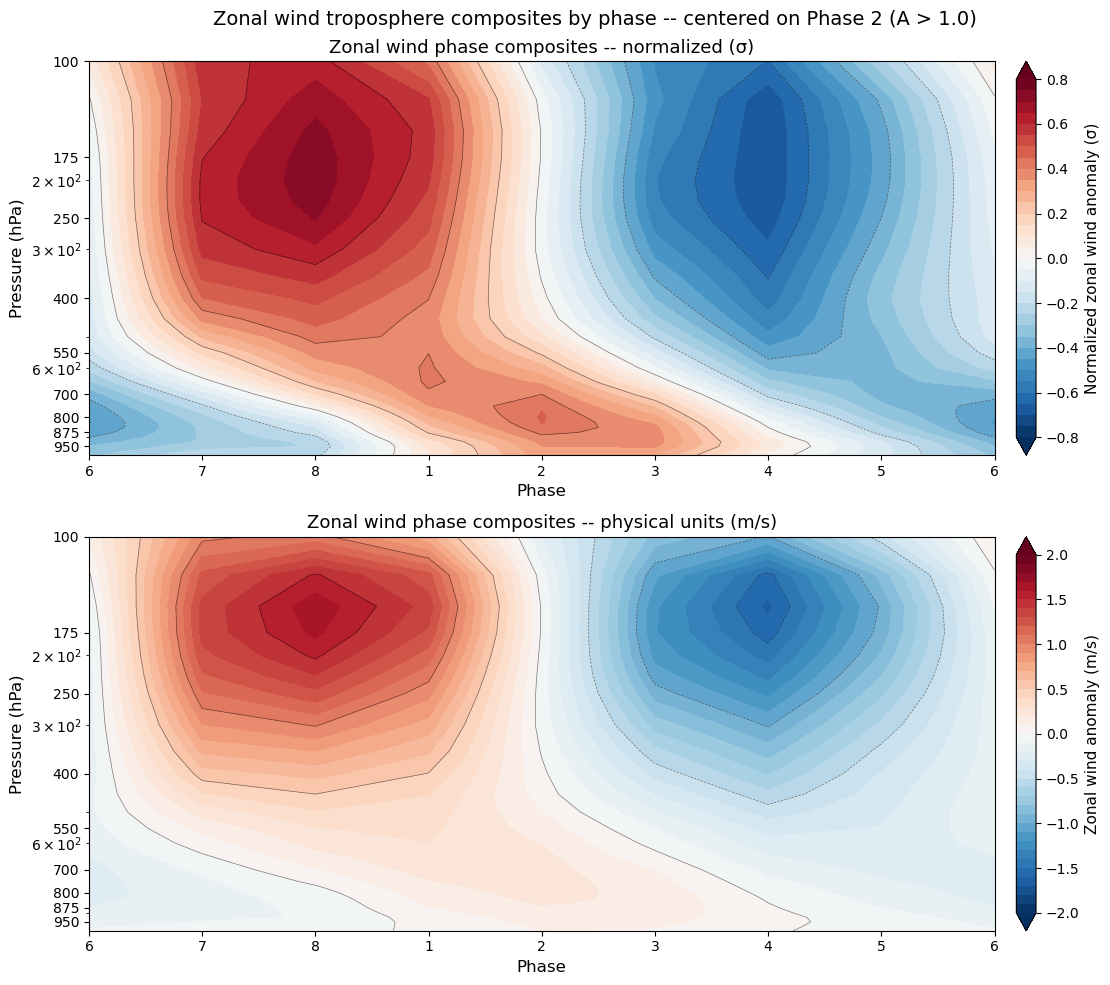

In [38]:
u_levels = u_trop.level.values

comp_u_norm_centered     = comp_u_norm[:, phase_order]     # shape (27, 9)
comp_u_physical_centered = comp_u_physical[:, phase_order] # shape (27, 9)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, u_levels, comp_u_norm_centered,
    levels=np.arange(-0.8, 0.81, 0.05),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, u_levels, comp_u_norm_centered,
    levels=np.arange(-0.8, 0.81, 0.2),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Zonal wind phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(u_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized zonal wind anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, u_levels, comp_u_physical_centered,
    levels=np.arange(-2.0, 2.01, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, u_levels, comp_u_physical_centered,
    levels=np.arange(-2.0, 2.01, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Zonal wind phase composites -- physical units (m/s)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(u_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('Zonal wind anomaly (m/s)', fontsize=11)

plt.suptitle('Zonal wind troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('u_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()